# Asset Allocation Strategy Project

In [2]:
# !pip install yfinance #installing yfinance using !pip in ipynb
# # Terminal
# pip install yfinance

# # OR inside Jupyter notebook
# !pip install yfinance

# Terminal
# pip install PyPortfolioOpt

# Inside Jupyter notebook
# !pip install PyPortfolioOpt

# module used from above 
# from pypfopt import EfficientFrontier
# from pypfopt import risk_models, expected_returns


In [9]:
#importing the packages needed for this project

import yfinance as yf
import pandas as pd
import numpy as np
import scipy 
import matplotlib 
import seaborn as sb
import pypfopt

## Phase 1 - Data Collection
### using yfinance to pull historical price data for the asset classes (equities, bonds, and commodities)
### calculate log return from daily prices - more statistically well-behaved than simple returns

In [10]:
tickers = [
    #defensive and non-tech stocks
    'JNJ',   # Healthcare
    'KO',    # Consumer Staples
    'EOG',   # Energy
    'NEM',   # Gold / Commodities
    'ADM',   # Agriculture

    #large-cap tech stocks
    'MSFT',  # Cloud / AI / Software

    #mid-cap tech stocks
    'ADBE',  # Software
    'AMAT',  # Semiconductors

    #high growth tech stock
    'NVDA',  # AI Chips
]  #a list of 

data = yf.download(tickers, start='2015-01-01', end='2025-01-01', threads = False)['Close'] #10 years

[*********************100%***********************]  9 of 9 completed


In [ ]:
log_returns = np.log(data / data.shift(1)).dropna() #drop any blank or na

# save log returns into csv for phase 2
log_returns.to_csv('log_returns.csv')

## Phase 2 - Porfolio Statistics
### Compute expected returns and the covariance matrix accross assets
### Derive portfolio-level return, volatility and sharp ratio (return per unit of risk)

In [17]:
# # load csv from phase 1 
# log_returns = pd.read_csv('log_returns.csv', index_col=0, parse_dates=True)

# #show the csv
# log_returns

In [13]:
#calculating the annualized expected returns 
mean_returns = log_returns.mean() * 252

print(f"Mean returns", mean_returns)

Mean returns Ticker
ADBE    0.181959
ADM     0.025591
AMAT    0.200521
EOG     0.056421
JNJ     0.060192
KO      0.070970
MSFT    0.235581
NEM     0.088701
NVDA    0.563863
dtype: float64


In [19]:
#calculating the cov matrix
cov_matrix = log_returns.cov() * 252

#print out the covariance matrix
print("Covariance Matrix shape:", cov_matrix.shape) #9x9 matrix
print("Covariance Matrix:\n", cov_matrix) #print out the matrix

Covariance Matrix shape: (9, 9)
Covariance Matrix:
 Ticker      ADBE       ADM      AMAT       EOG       JNJ        KO      MSFT  \
Ticker                                                                         
ADBE    0.111180  0.022865  0.072497  0.029395  0.017091  0.018308  0.063957   
ADM     0.022865  0.073653  0.036514  0.045903  0.017750  0.020908  0.024617   
AMAT    0.072497  0.036514  0.163220  0.050868  0.018329  0.021176  0.065214   
EOG     0.029395  0.045903  0.050868  0.163244  0.015684  0.019551  0.029633   
JNJ     0.017091  0.017750  0.018329  0.015684  0.032672  0.016551  0.018778   
KO      0.018308  0.020908  0.021176  0.019551  0.016551  0.031917  0.019629   
MSFT    0.063957  0.024617  0.065214  0.029633  0.018778  0.019629  0.073608   
NEM     0.010327  0.014402  0.017344  0.023187  0.008630  0.011813  0.011575   
NVDA    0.091549  0.027997  0.126996  0.040164  0.015020  0.017171  0.079706   

Ticker       NEM      NVDA  
Ticker                      
ADBE    0

In [25]:
def portfolio_stats(weights, mean_returns, cov_matrix, risk_free_rate=0.05):
    weights = np.array(weights)
    
    port_return = np.dot(weights, mean_returns)
    port_volatility = np.sqrt(weights.T @ cov_matrix @ weights)
    sharpe_ratio = (port_return - risk_free_rate) / port_volatility
    
    return port_return, port_volatility, sharpe_ratio


In [26]:
num_portfolios = 10000
num_assets = len(mean_returns)
results = np.zeros((3, num_portfolios))
weights_record = []

for i in range(num_portfolios):
    weights = np.random.dirichlet(np.ones(num_assets))  # sums to 1
    weights_record.append(weights)
    
    ret, vol, sharpe = portfolio_stats(weights, mean_returns, cov_matrix)
    results[0, i] = ret
    results[1, i] = vol
    results[2, i] = sharpe  # used for color coding


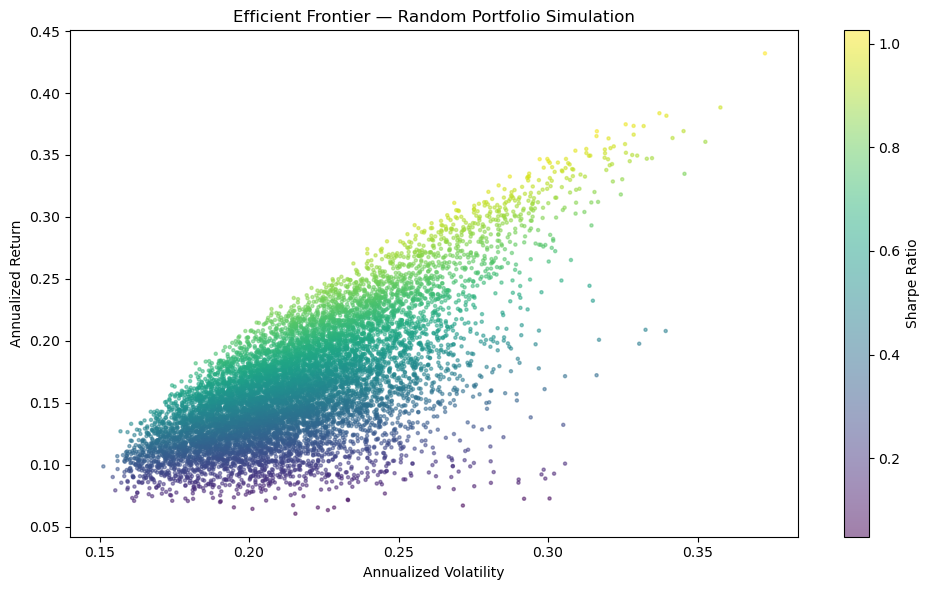

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(results[1, :], results[0, :],
            c=results[2, :], cmap='viridis', alpha=0.5, s=5)
plt.colorbar(label='Sharpe Ratio')
plt.xlabel('Annualized Volatility')
plt.ylabel('Annualized Return')
plt.title('Efficient Frontier — Random Portfolio Simulation')
plt.tight_layout()
plt.savefig('efficient_frontier_cloud.png')
plt.show()


In [29]:
import pandas as pd

tickers = ['JNJ', 'KO', 'EOG', 'NEM', 'ADM', 'MSFT', 'ADBE', 'AMAT', 'NVDA']
weights_array = np.array(weights_record)

# --- Max Sharpe Portfolio ---
max_sharpe_idx = np.argmax(results[2, :])
max_sharpe_weights = weights_array[max_sharpe_idx]
max_sharpe_ret = results[0, max_sharpe_idx]
max_sharpe_vol = results[1, max_sharpe_idx]

# --- Min Volatility Portfolio ---
min_vol_idx = np.argmin(results[1, :])
min_vol_weights = weights_array[min_vol_idx]
min_vol_ret = results[0, min_vol_idx]
min_vol_vol = results[1, min_vol_idx]

# --- Print as DataFrames ---
print("=== Max Sharpe Portfolio ===")
print(f"Return: {max_sharpe_ret:.2%} | Volatility: {max_sharpe_vol:.2%} | Sharpe: {results[2, max_sharpe_idx]:.2f}")
print(pd.Series(max_sharpe_weights, index=tickers).apply(lambda x: f"{x:.2%}"))

print("\n=== Min Volatility Portfolio ===")
print(f"Return: {min_vol_ret:.2%} | Volatility: {min_vol_vol:.2%} | Sharpe: {results[2, min_vol_idx]:.2f}")
print(pd.Series(min_vol_weights, index=tickers).apply(lambda x: f"{x:.2%}"))


=== Max Sharpe Portfolio ===
Return: 43.20% | Volatility: 37.25% | Sharpe: 1.03
JNJ      3.95%
KO       0.80%
EOG      4.77%
NEM      1.52%
ADM      6.43%
MSFT     1.96%
ADBE     3.39%
AMAT     7.19%
NVDA    69.98%
dtype: object

=== Min Volatility Portfolio ===
Return: 9.86% | Volatility: 15.13% | Sharpe: 0.32
JNJ      0.28%
KO       0.73%
EOG      1.60%
NEM      2.18%
ADM     42.22%
MSFT    33.96%
ADBE     3.47%
AMAT    10.94%
NVDA     4.63%
dtype: object


In [28]:
mean_returns.to_csv('mean_returns.csv')
cov_matrix.to_csv('cov_matrix.csv')


In [31]:
# Phase 3


In [33]:
!pip install PyPortfolioOpt

from pypfopt import EfficientFrontier, risk_models, expected_returns
from pypfopt.discrete_allocation import DiscreteAllocation, get_latest_prices
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [35]:
# Load price data from Phase 1
prices = pd.read_csv('log_returns.csv', index_col=0, parse_dates=True)

# Recompute mu and S using PyPortfolioOpt's built-in methods
mu = expected_returns.mean_historical_return(prices)  # annualized expected returns
S = risk_models.sample_cov(prices)                    # annualized covariance matrix

print(mu)
print(S)


ADBE   NaN
ADM    NaN
AMAT   NaN
EOG    NaN
JNJ    NaN
KO     NaN
MSFT   NaN
NEM    NaN
NVDA   NaN
dtype: float64
               ADBE           ADM          AMAT            EOG           JNJ  \
ADBE  184613.279142   -938.717161    657.964603    -228.497582 -2.359835e+03   
ADM     -938.717161  26395.316939   -903.622166    -432.376809 -1.004170e+04   
AMAT     657.964603   -903.622166  84941.821875      89.957141  4.084671e+02   
EOG     -228.497582   -432.376809     89.957141  116567.042918 -5.368367e+04   
JNJ    -2359.834968 -10041.703743    408.467146  -53683.673720  7.153225e+07   
KO      1342.576874    766.528207     48.483546    -370.203125  2.117294e+03   
MSFT   12371.280934    536.309858   -591.205601    3728.494623  5.679549e+03   
NEM     -506.471319    -96.802915    880.515397      45.254644  8.591921e+03   
NVDA    -228.805527   1045.642874   -888.877716    -918.808581  1.583321e+03   

                KO           MSFT           NEM           NVDA  
ADBE   1342.576874  

c:\Users\User\anaconda3\Lib\site-packages\pypfopt\expected_returns.py:32: UserWarning: Some returns are NaN. Please check your price data.
  warnings.warn(
c:\Users\User\anaconda3\Lib\site-packages\pypfopt\expected_returns.py:36: UserWarning: Some returns are infinite. Please check your price data.
  warnings.warn(
c:\Users\User\anaconda3\Lib\site-packages\numpy\_core\_methods.py:55: RuntimeWarning: invalid value encountered in reduce
  return umr_prod(a, axis, dtype, out, keepdims, initial, where)


In [36]:
ef = EfficientFrontier(mu, S)
ef.max_sharpe(risk_free_rate=0.05)
sharpe_weights = ef.clean_weights()  # removes near-zero weights

ret, vol, sharpe = ef.portfolio_performance(verbose=True, risk_free_rate=0.05)

print("\n=== Max Sharpe Weights ===")
print(pd.Series(sharpe_weights))


ValueError: Problem data contains NaN or Inf. Check your parameter values and constants.

In [24]:
#implementing MVO from scratch using scipy
import numpy as np
from scipy.optimize import minimize

# Objective: minimize portfolio variance
def portfolio_variance(weights, cov_matrix):
    return weights.T @ cov_matrix @ weights

# Solve for minimum variance at a given target return
def markowitz_optimize(mean_returns, cov_matrix, target_return):
    n = len(mean_returns)
    constraints = [
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},               # weights sum to 1
        {'type': 'eq', 'fun': lambda w: w @ mean_returns - target_return}  # hit target return
    ]
    bounds = [(0, 1) for _ in range(n)]   # no short selling
    result = minimize(portfolio_variance, x0=np.ones(n)/n,
                      args=(cov_matrix,), method='SLSQP',
                      bounds=bounds, constraints=constraints)
    return result.x

# Sweep target returns to trace the full frontier
target_returns = np.linspace(mean_returns.min(), mean_returns.max(), 100)
frontier_weights = [markowitz_optimize(mean_returns, cov_matrix, r) for r in target_returns]
frontier_vols = [np.sqrt(w @ cov_matrix @ w) for w in frontier_weights]

In [23]:
#or use pyportfolio for cleaner code
#from pypfopt import EfficientFrontier, expected_returns, risk_models

mu = expected_returns.mean_historical_return(prices)
S = risk_models.sample_cov(prices)

ef = EfficientFrontier(mu, S)
weights = ef.min_volatility()        # Minimum Variance Portfolio
# or
weights = ef.max_sharpe()            # Tangency Portfolio (on the frontier)


NameError: name 'expected_returns' is not defined

In [8]:
## Phase 3 - Optimization via 
### Run MC simulation with n random weight combinations (n must be > 5000)
### MVO 

## Phase 4 - Compare Allocation Strategies
### Equal weight, max sharpe ratio, risk parity, inverse volatility

## Phase 5 - Visualize Diversification
### Plot individual asset volatilities vs. portfolio volatility to visually demonstrate risk reduction
### Show correlation heatmaps 